# 17. Synthetic trees, plots and scans

`sylva.synthetic` makes point clouds whose right answer is known, so that a
method can be checked against the truth rather than against another method.
Notebooks 3, 6, 7 and 9 use the realistic generators shown here:
`tree_model` grows a tree from an archetype with its cylinders, leaves and
leaf angles as the truth; `plot` makes a mixed stand on rough ground with
understorey and dead wood and a truth table; and `scan` with a finite beam
scans either one with range noise, a beam footprint, mixed pixels and
multiple returns. The [guide](../guide/synthetic.md) describes the models
and the checks behind them.

In [1]:
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

tmp = Path(tempfile.mkdtemp())      # files written here are temporary
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set

import pandas as pd
from sylva import filters

## Five archetypes

Each archetype sets the architecture (where the crown starts, how the stem
forks, how branches bend), the crown shape and the leaves: their size and
their angle distribution. Every tree here has a DBH of 30 cm and a target
height of 16 m, except the shrub: 4 m, with 3 cm stems.

In [2]:
names = ["broadleaf", "conifer", "eucalypt", "savanna", "shrub"]
models = {n: synthetic.tree_model(n, dbh=0.03 if n == "shrub" else 0.3, height=4.0 if n == "shrub" else 16.0,
                                  seed=2) for n in names}
pd.DataFrame.from_dict({n: {"DBH (cm)": 100 * t.dbh, "height (m)": t.height, "crown base (m)": t.crown_base,
                  "wood volume (L)": 1000 * t.qsm.total_volume, "stem share of the wood": t.qsm.stem_volume / t.qsm.total_volume,
                  "leaf area (m2)": t.leaf_area, "leaves": len(t.leaves["area"]),
                  "mean leaf angle (deg)": t.leaf_angles().mean_deg}
              for n, t in models.items()}, orient="index").round(2)

,DBH (cm),height (m),crown base (m),wood volume (L),stem share of the wood,leaf area (m2),leaves,mean leaf angle (deg)
broadleaf,30.0,16.22,5.64,586.46,0.78,134.98,34372,26.81
conifer,30.0,16.04,4.06,455.24,0.85,83.13,176416,57.29
eucalypt,30.0,15.28,8.84,406.07,0.94,48.25,13651,63.39
savanna,30.0,15.01,3.21,538.16,0.50,81.00,171885,26.78
shrub,3.0,4.48,0.34,2.52,0.09,2.70,2755,57.55


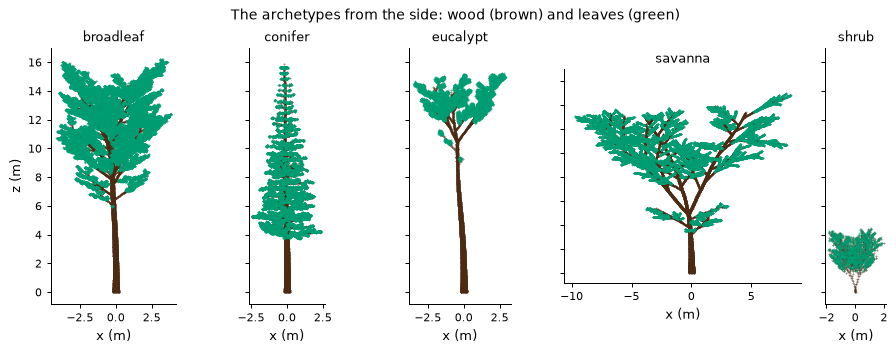

In [3]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3.8), sharey=True, gridspec_kw={"width_ratios": [1, 0.8, 1, 1.3, 0.5]})
for a, (name, t) in zip(ax, models.items()):
    c = t.points[::4]
    wood = c.attrs["classification"] == 5
    a.scatter(c.x[wood] - t.base[0], c.z[wood], s=0.1, c=WOOD)
    a.scatter(c.x[~wood] - t.base[0], c.z[~wood], s=0.1, c=LEAF)
    a.set(aspect="equal", title=name, xlabel="x (m)")
ax[0].set_ylabel("z (m)")
fig.suptitle("The archetypes from the side: wood (brown) and leaves (green)");

The truth of a tree is complete: `t.qsm` is its wood as a table of
cylinders (the points lie on them), `t.leaves` lists every leaf with its
centre, normal and area, and `t.leaf_angles()` gives the leaf angle
distribution and its G function. The leaf angles below are each archetype's
default: planophile (mostly horizontal) blades for the broadleaf and the
savanna tree, erectophile (hanging) leaves for the eucalypt, and spherical
for the conifer's shoots and the shrub.

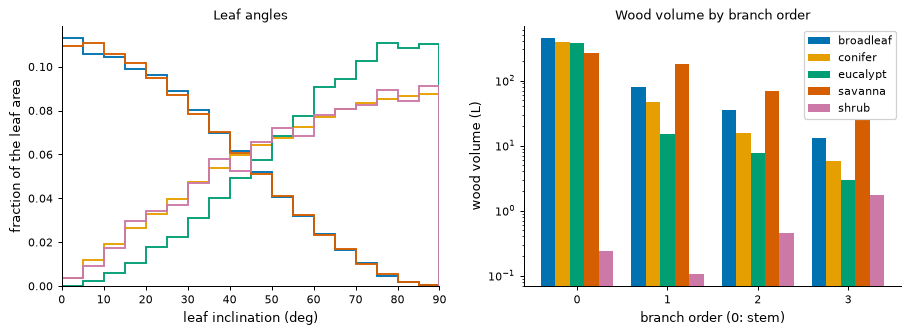

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
edges = np.linspace(0, 90, 19)
for i, (name, t) in enumerate(models.items()):
    inc = np.degrees(np.arccos(np.abs(t.leaves["normal"][:, 2])))
    h = np.histogram(inc, edges, weights=t.leaves["area"])[0]
    ax[0].stairs(h / h.sum(), edges, color=f"C{i}", lw=1.5, label=name)
    order = t.volume_by_order()
    ax[1].bar(np.array(list(order)) + 0.16 * (i - 2), 1000 * np.array(list(order.values())), width=0.16,
              color=f"C{i}", label=name)
ax[0].set(xlabel="leaf inclination (deg)", ylabel="fraction of the leaf area", xlim=(0, 90), title="Leaf angles")
ax[1].set(xlabel="branch order (0: stem)", ylabel="wood volume (L)", yscale="log", xticks=range(4),
          title="Wood volume by branch order")
ax[1].legend(loc="upper right");

## A stand

`plot` draws stem diameters from a distribution (here a Weibull), gives
each tree an archetype by weight and a height from the archetype's
height-diameter curve, places the stems without overlap, and adds terrain
with a slope and micro-relief, shrubs, grass, fallen logs and stumps. Every
point carries a `label`; the trees come with a truth table.

In [5]:
p = synthetic.plot(size=30, density=600, archetypes={"broadleaf": 1, "eucalypt": 1, "conifer": 1},
                   slope=0.15, roughness=0.08, seed=1)
print(f"{len(p.points):,} points; {p.stem_density:.0f} stems/ha, basal area {p.basal_area:.1f} m2/ha, "
      f"leaf area index of the trees {p.trees['leaf_area'].sum() / 30**2:.2f}")
pd.DataFrame(p.trees)[["tree_id", "archetype", "dbh", "height", "crown_base", "wood_volume", "leaf_area"]].head(6).round(2)

4,848,905 points; 600 stems/ha, basal area 27.6 m2/ha, leaf area index of the trees 3.40


,tree_id,archetype,dbh,height,crown_base,wood_volume,leaf_area
0,1,broadleaf,0.47,29.15,10.23,2.36,334.04
1,2,eucalypt,0.44,27.78,15.31,1.39,104.94
2,3,eucalypt,0.42,28.13,15.11,1.27,97.68
3,4,eucalypt,0.41,29.80,16.05,1.23,90.06
4,5,conifer,0.40,26.65,6.70,1.23,139.07
5,6,conifer,0.37,24.11,6.04,0.93,117.10


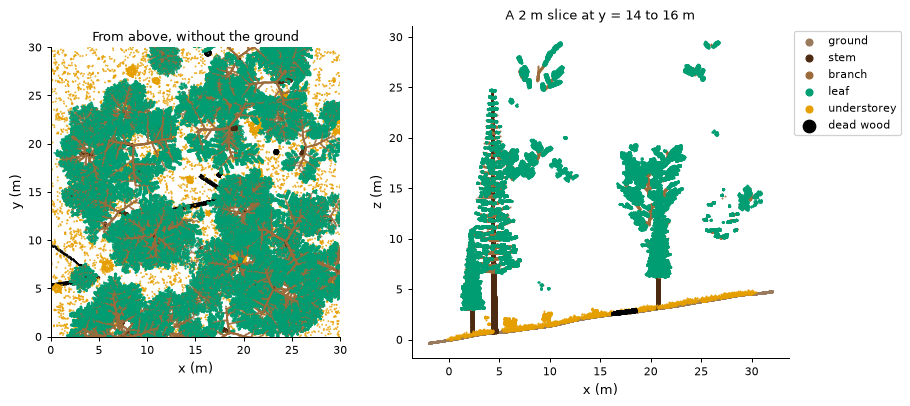

In [6]:
LABEL_COLOURS = {1: ("ground", GROUND), 2: ("stem", WOOD), 3: ("branch", "#9C6B3C"), 4: ("leaf", LEAF),
                 5: ("understorey", GRASS), 6: ("dead wood", "k")}
label = p.points.attrs["label"]
fig, ax = plt.subplots(1, 2, figsize=(10, 4.4), gridspec_kw={"width_ratios": [1, 1.4]})
s = p.points[::10]
s = s[s.attrs["label"] != 1]                  # the ground, which the side view shows
order = np.argsort(s.z)
colours = np.array([LABEL_COLOURS[v][1] for v in range(1, 7)], dtype=object)[s.attrs["label"][order] - 1]
ax[0].scatter(s.x[order], s.y[order], c=list(colours), s=0.2)
ax[0].set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title="From above, without the ground", xlim=(0, 30), ylim=(0, 30))
slab = np.abs(p.points.y - 15) < 1.0
for v, (name, colour) in LABEL_COLOURS.items():
    k = slab & (label == v)
    ax[1].scatter(p.points.x[k], p.points.z[k], s=0.3 if v != 6 else 1.0, c=colour, label=name)
ax[1].set(aspect="equal", xlabel="x (m)", ylabel="z (m)", title="A 2 m slice at y = 14 to 16 m")
ax[1].legend(markerscale=10, loc="upper left", bbox_to_anchor=(1.0, 1.0));

## A scan with a finite beam

Any beam option switches `scan` from taking the nearest point in each
angular cell to casting a beam: a cone of the scanner's divergence from its
exit aperture, sampled by sub-beams, with each point standing for a small
patch of surface. Hits closer in range than the receiver's resolution
merge into one echo at their energy-weighted mean range, which is how a
footprint straddling a stem's edge puts a point in the gap behind it: a
mixed pixel. Range noise is added along the beam. Here the stand is scanned
from its centre with the model of a RIEGL VZ-400.

In [7]:
x0, y0 = 15.0, 15.0
origin = (x0, y0, p.ground_height(x0, y0) + 1.5)
shots = synthetic.scan(p.points, origin=origin, resolution_deg=0.06, scanner="vz400", range_noise=0.005, seed=1)
echoes = shots.to_pointcloud()
spread = echoes.attrs["range_spread"]
print(shots)
print(f"echoes per pulse: {dict(enumerate(np.bincount(shots.echo_count).tolist()))}; "
      f"mixed pixels (hits spread over more than 5 cm in range): {np.mean(spread > 0.05):.1%} of the echoes")

Shots(n_shots=10,002,000, n_echoes=7,599,243)
echoes per pulse: {0: 2954141, 1: 6496475, 2: 551384}; mixed pixels (hits spread over more than 5 cm in range): 11.0% of the echoes


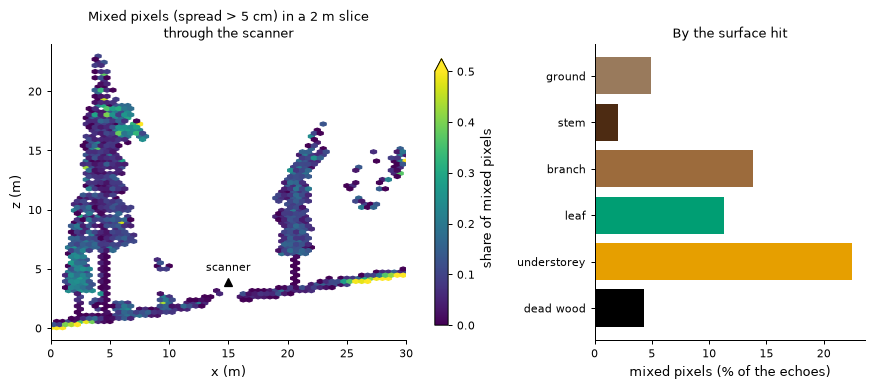

In [8]:
mixed = spread > 0.05
label = echoes.attrs["label"]
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
slab = np.abs(echoes.y - y0) < 1.0
hb = ax[0].hexbin(echoes.x[slab], echoes.z[slab], C=mixed[slab], reduce_C_function=np.mean, gridsize=(60, 48),
                  mincnt=5, vmin=0, vmax=0.5, extent=(0, 30, -1, 24))
fig.colorbar(hb, ax=ax[0], shrink=0.9, label="share of mixed pixels", extend="max")
ax[0].plot(*origin[::2], "k^", ms=7)
ax[0].annotate("scanner", origin[::2], xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8.5)
ax[0].set(aspect="equal", xlabel="x (m)", ylabel="z (m)", xlim=(0, 30), ylim=(-1, 24),
          title="Mixed pixels (spread > 5 cm) in a 2 m slice\nthrough the scanner")
names = {v: n for v, (n, _) in LABEL_COLOURS.items()}
kinds = [v for v in names if np.any(label == v)]
ax[1].barh([names[v] for v in kinds], [100 * mixed[label == v].mean() for v in kinds],
           color=[LABEL_COLOURS[v][1] for v in kinds])
ax[1].invert_yaxis()
ax[1].set(xlabel="mixed pixels (% of the echoes)", title="By the surface hit");

Mixed pixels gather where surfaces lie within the receiver's range
resolution of each other: in the foliage, where a footprint falls on a leaf
and the leaves just behind it, in the grass and shrubs, and on the ground
far from the scanner, where the footprint grazes it and spreads along it in
range. A stem seen
against the distant background gives two separate returns at its edge
instead, which is why stems and the ground come out cleanest. Every echo
keeps the attributes of its strongest target (`classification`, `label`,
`tree_id`), so each of these errors can be traced back to its cause.